<a href="https://colab.research.google.com/github/CesarB2025/FICO-challenge/blob/main/Week_4_5_Feature_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FICO Analytic Challenge Week 4.5 Solutions
##© Fair Isaac 2024

In [ ]:
import os
import sys
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
# Defining projects path and directory locations
path = '/content/drive/MyDrive/FICO Analytic Challenge/'
sys.path.append(path +'Data')
sys.path.append(path +'Week 04')
os.chdir(path)
print(os.getcwd())

/content/drive/MyDrive/FICO Analytic Challenge


In [ ]:
# Data and numerical libararies
import pandas as pd
import numpy as np

# Plotting and stats library
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings('ignore')

# Removing limitation in viewing pandas columns and rows
pd.set_option('display.max_columns', None, 'display.max_rows', None)

In [ ]:
# Folder's name that's holding dataset
data = 'Data'

In [ ]:
# dataset file prefix
trainFile = ['train']
testFile = ['test_C']

# CSV filename and where features dataset will be saved
featureTrainFileSuffix="_advanced_features.csv"
featureTestFileSuffix="_advanced_features.csv"

filePathTrain=os.path.join(path + data, trainFile[0] + featureTrainFileSuffix)
filePathTest=os.path.join(path + data, testFile[0] + featureTestFileSuffix)

if not os.path.isfile(filePathTrain):
    featureTrainFileSuffix="_features.csv"

if not os.path.isfile(filePathTest):
    featureTestFileSuffix="_features.csv"

trainsaveCSV = os.path.join(path + data, trainFile[0] + featureTrainFileSuffix)
testsaveCSV = os.path.join(path + data, testFile[0] + featureTestFileSuffix)

In [ ]:
# function to import dataset
def modify_df(filename, path, data):
    filePath=os.path.join(path + data, filename[0] + "_advanced_features.csv")

    if not os.path.isfile(filePath):
        filePath=os.path.join(path + data, filename[0] + "_features.csv")

    df1 = pd.read_csv(filePath)
    df1['transactionDateTime'] = pd.to_datetime(df1['transactionDateTime']).astype('datetime64[ns]')
    df1 = df1.sort_values(by=['pan','transactionDateTime'])

    return df1

In [ ]:
#Upload pre-processed data
df1 = modify_df(trainFile, path, data)
df2 = modify_df(testFile, path, data)

In [ ]:
#Combine dataframes to be processed together
df = pd.concat([df1,df2])

In [ ]:
#It often helps to decompose the datetime into more useful fields
df['datetime'] =  pd.to_datetime(df['transactionDateTime'])
df['transactionHour'] = df['datetime'].dt.hour

#Since many of our features will be calculated at the account level, let's sort our features accordingly
df = df.sort_values(by=['pan', 'transactionDateTime'])

#When reordering data, it's customary to reset the index to align with the order of the rows
#df.reset_index(drop=True, inplace=True)

In [ ]:
#Sometimes it's convenient to create an array of the base variables before we start defining features
base_cols = ['pan', 'merchant', 'category', 'transactionAmount', 'first', 'last', 'mdlIsFraudTrx', 'mdlIsFraudAcct',
             'is_train', 'cardholderCountry', 'cardholderState', 'transactionDateTime', 'gender',
             'street', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
             'merch_lat', 'merch_long', 'merchCountry', 'merchState', 'deltaTime']

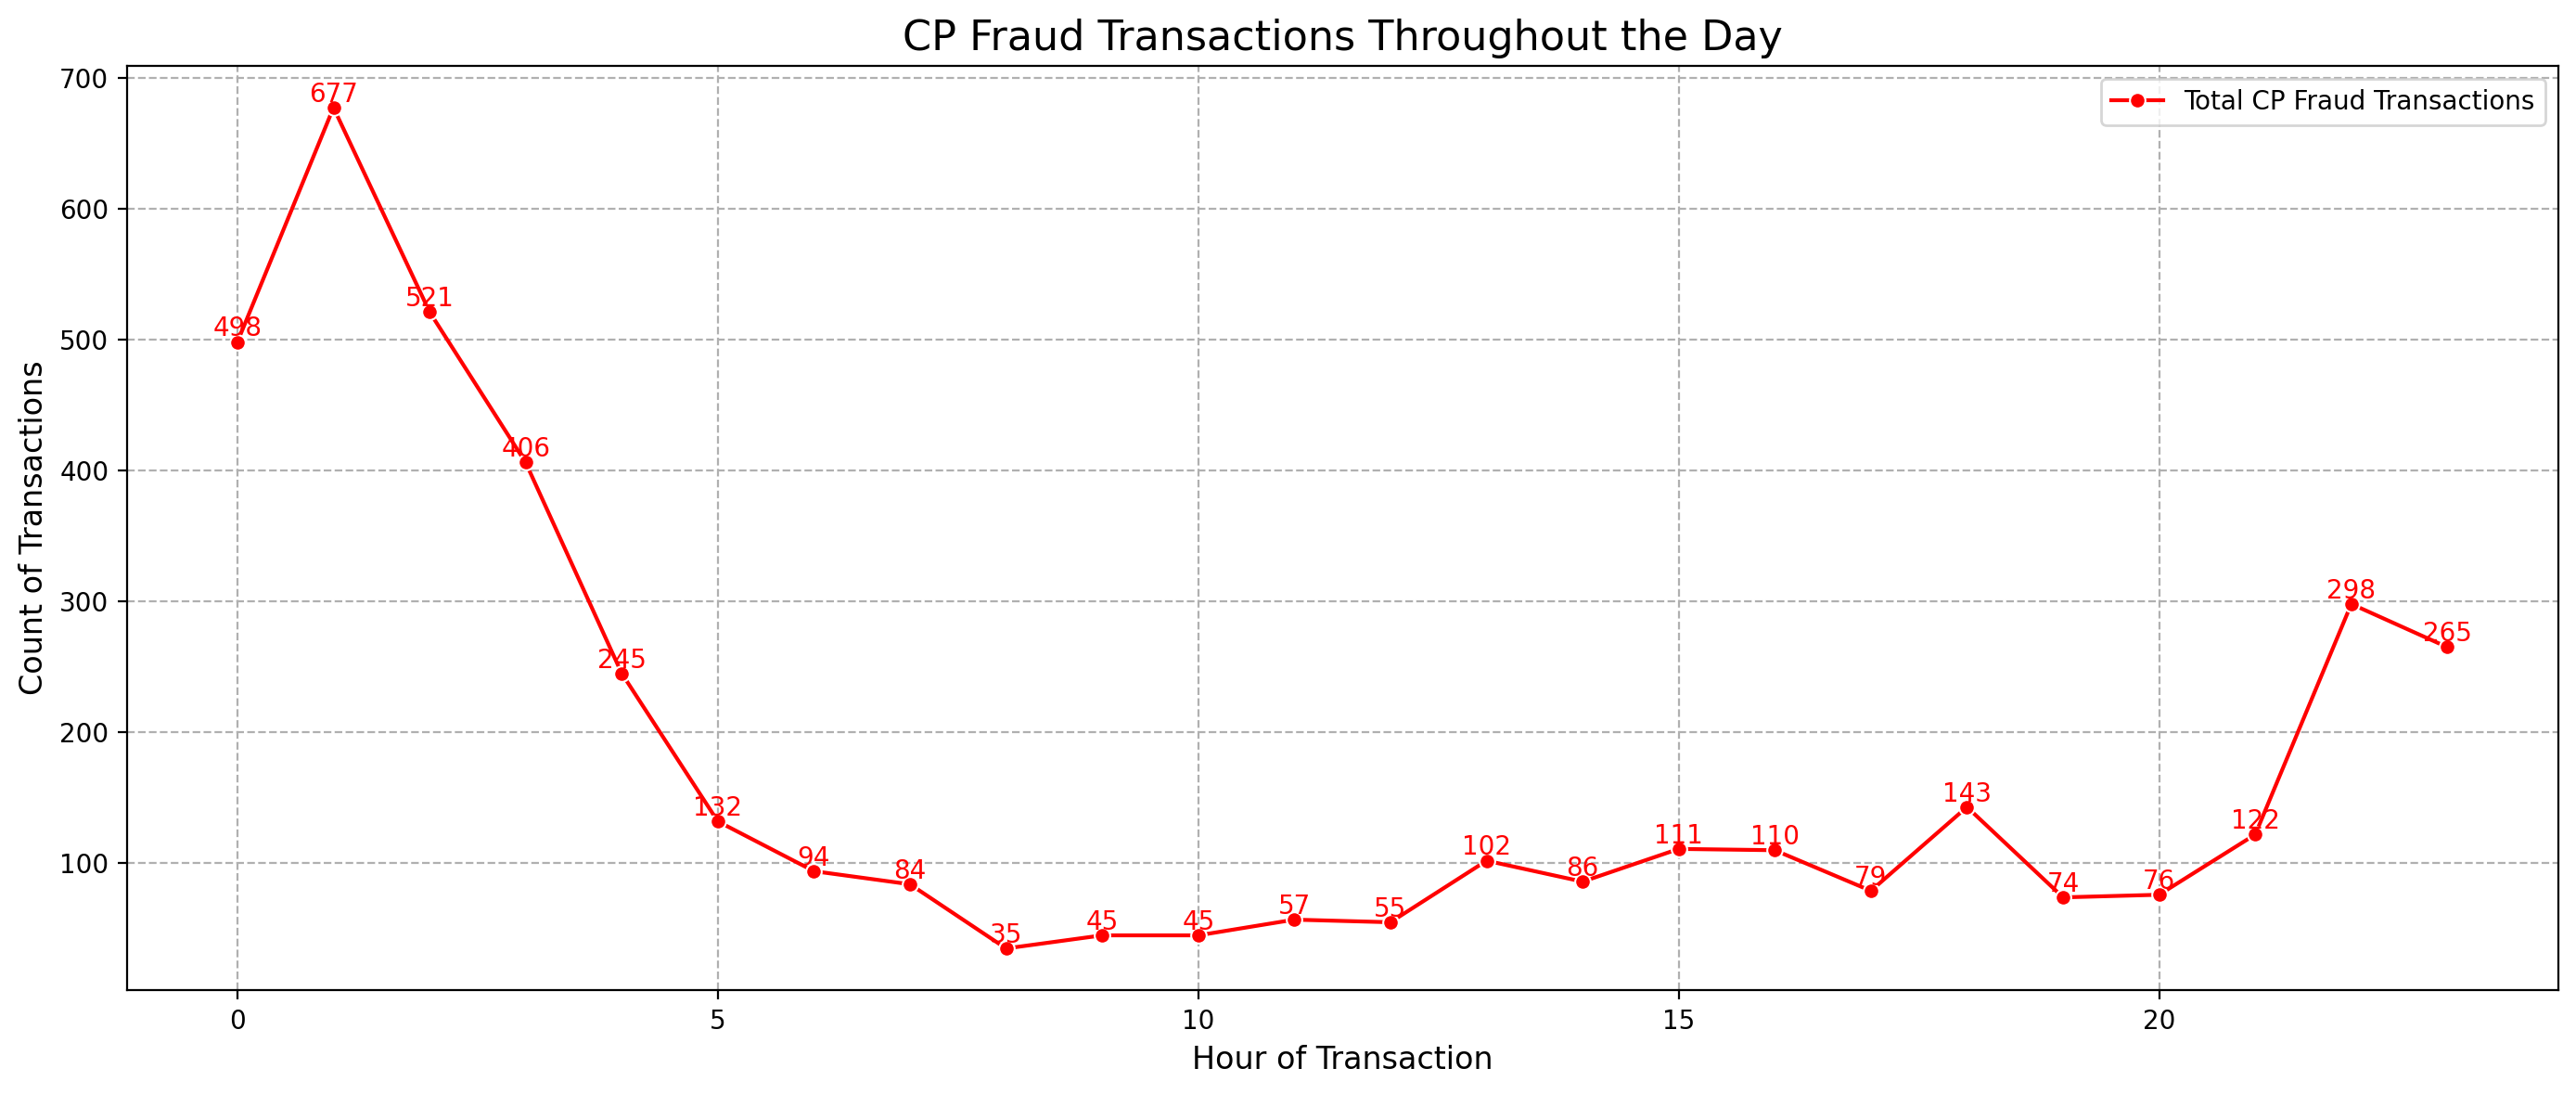

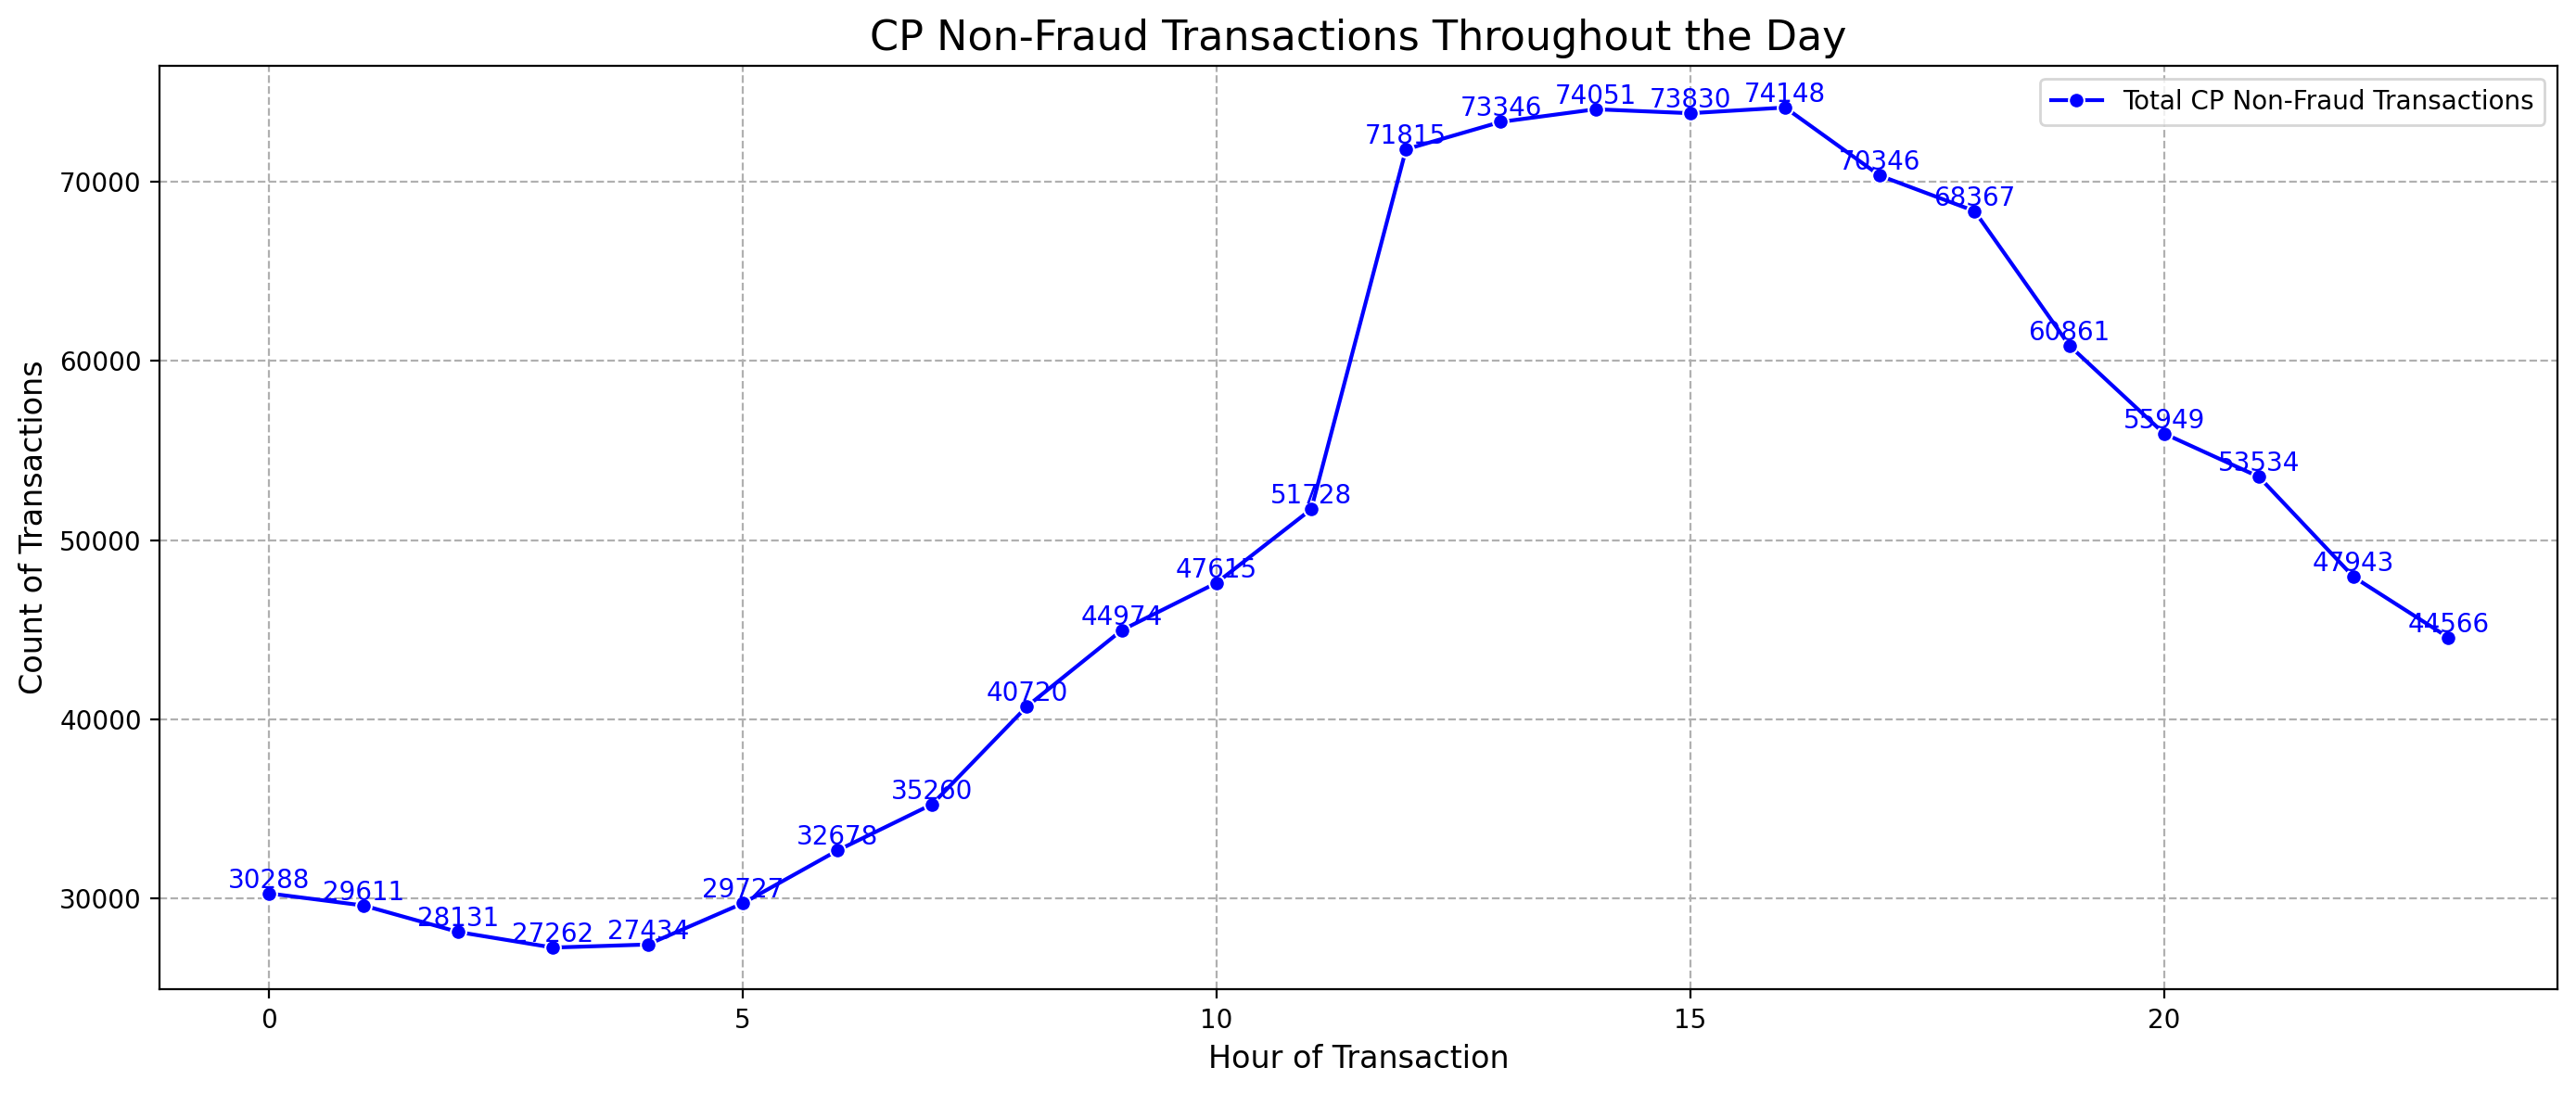

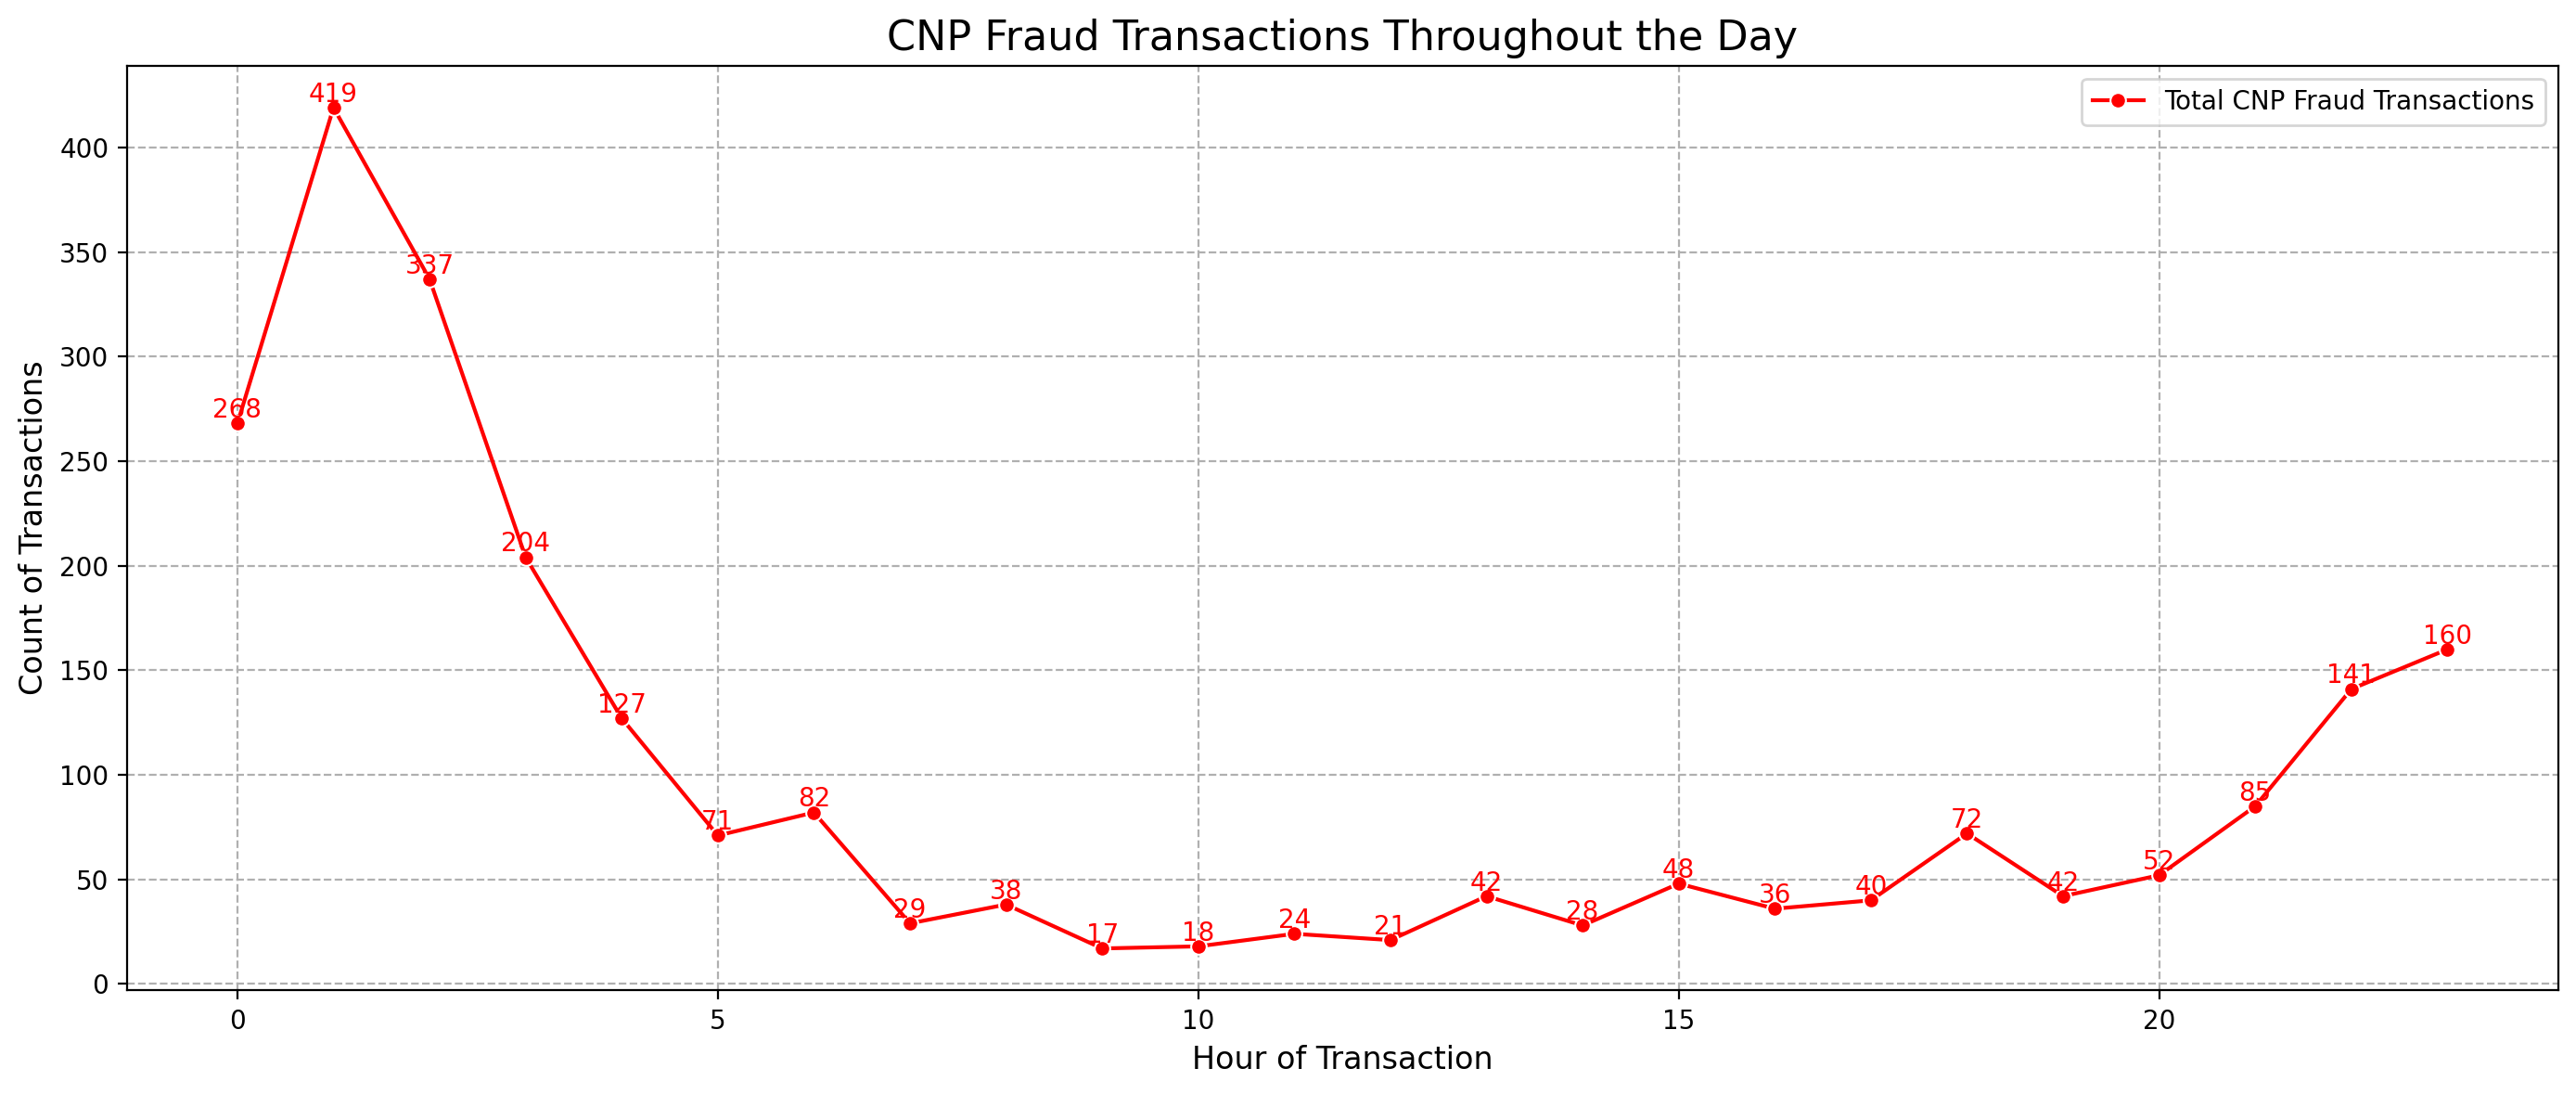

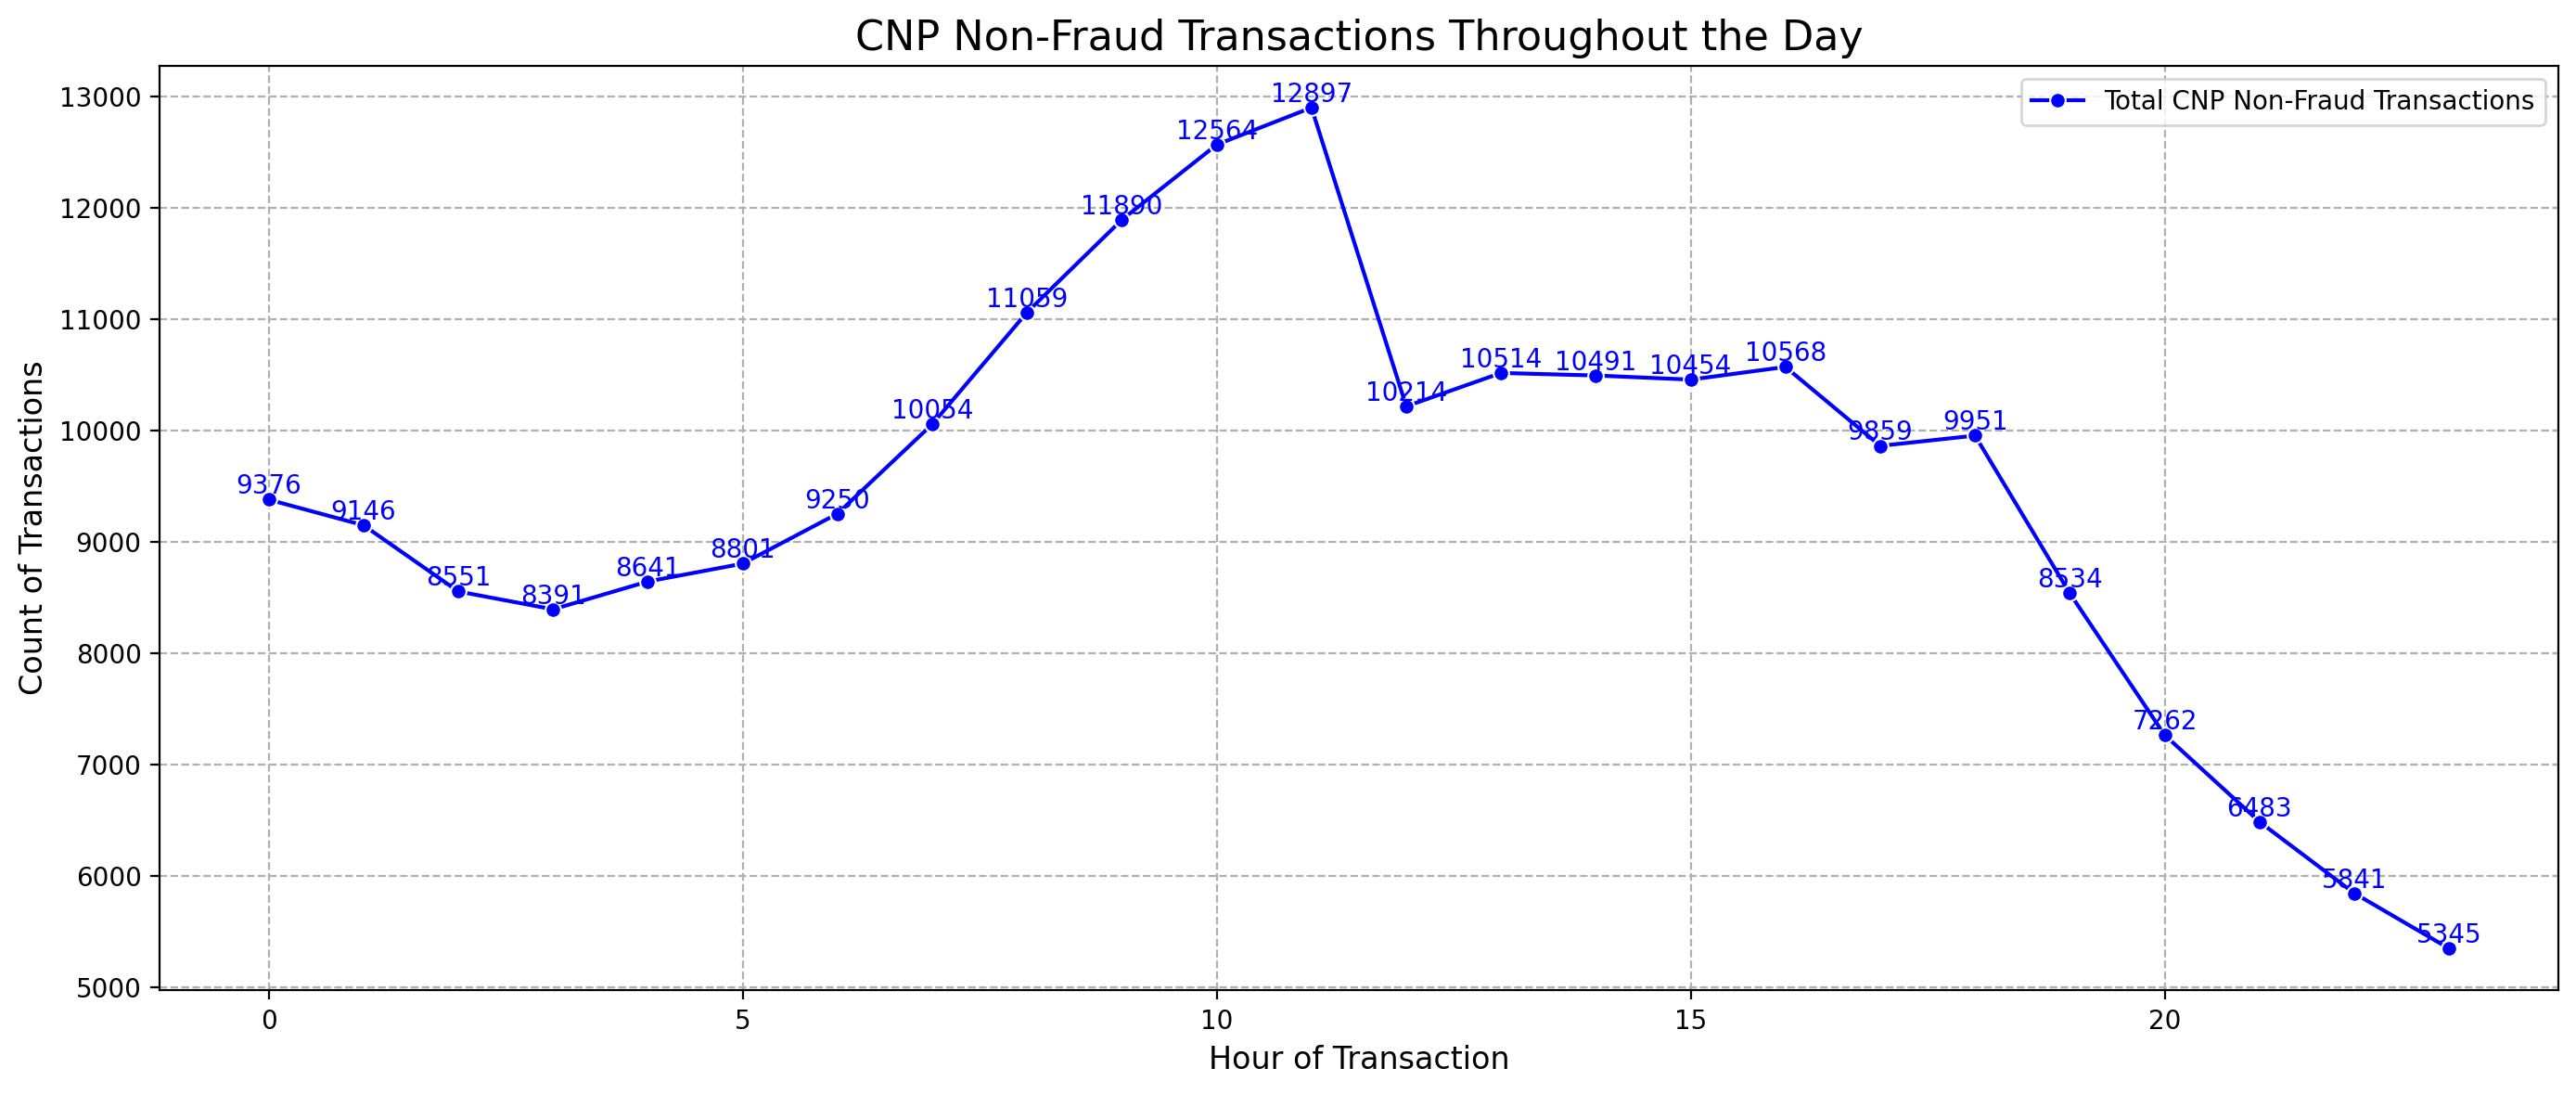

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from google.colab import drive
# drive.mount('/content/drive')


#df = pd.read_csv("/content/drive/MyDrive/FICO Analytic Challenge/Data/train.csv")

df['transactionDateTime'] = pd.to_datetime(df['transactionDateTime'])
df['transactionHour'] = df['transactionDateTime'].dt.hour

df['is_off_hours'] = ((df['transactionHour'] < 6) | (df['transactionHour'] > 23)).astype(int)
df['is_cnp'] = df['category'].apply(lambda x: 1 if x.endswith('_net') else 0)

cp_fraud_off_hours_count = df[(df['is_cnp'] == 0) & (df['is_off_hours'] == 1) & (df['mdlIsFraudTrx'] == 1)].groupby('transactionHour').size()
cp_non_fraud_off_hours_count = df[(df['is_cnp'] == 0) & (df['is_off_hours'] == 1) & (df['mdlIsFraudTrx'] == 0)].groupby('transactionHour').size()

total_cp_fraud_count = df[(df['is_cnp'] == 0) & (df['mdlIsFraudTrx'] == 1)].groupby('transactionHour').size()
total_cp_non_fraud_count = df[(df['is_cnp'] == 0) & (df['mdlIsFraudTrx'] == 0)].groupby('transactionHour').size()

total_transactions_df_cp = pd.DataFrame({
    'Total CP Fraud Transactions': total_cp_fraud_count,
    'Total CP Non-Fraud Transactions': total_cp_non_fraud_count
}).fillna(0).reset_index()

# CP Fraud Transactions
plt.figure(figsize=(14, 6))
sns.lineplot(x='transactionHour', y='Total CP Fraud Transactions', data=total_transactions_df_cp, color='red', label='Total CP Fraud Transactions', marker='o')
for i in range(len(total_transactions_df_cp)):
    plt.text(total_transactions_df_cp['transactionHour'][i], total_transactions_df_cp['Total CP Fraud Transactions'][i] + 0.1,
             f"{int(total_transactions_df_cp['Total CP Fraud Transactions'][i])}", color='red', ha="center", va="bottom", fontsize=10)

plt.title('CP Fraud Transactions Throughout the Day', fontsize=16)
plt.xlabel('Hour of Transaction', fontsize=12)
plt.ylabel('Count of Transactions', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Plot for CP Non-Fraud Transactions
plt.figure(figsize=(14, 6))
sns.lineplot(x='transactionHour', y='Total CP Non-Fraud Transactions', data=total_transactions_df_cp, color='blue', label='Total CP Non-Fraud Transactions', marker='o')
for i in range(len(total_transactions_df_cp)):
    plt.text(total_transactions_df_cp['transactionHour'][i], total_transactions_df_cp['Total CP Non-Fraud Transactions'][i] + 0.1,
             f"{int(total_transactions_df_cp['Total CP Non-Fraud Transactions'][i])}", color='blue', ha="center", va="bottom", fontsize=10)

plt.title('CP Non-Fraud Transactions Throughout the Day', fontsize=16)
plt.xlabel('Hour of Transaction', fontsize=12)
plt.ylabel('Count of Transactions', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

cnp_fraud_off_hours_count = df[(df['is_cnp'] == 1) & (df['is_off_hours'] == 1) & (df['mdlIsFraudTrx'] == 1)].groupby('transactionHour').size()
cnp_non_fraud_off_hours_count = df[(df['is_cnp'] == 1) & (df['is_off_hours'] == 1) & (df['mdlIsFraudTrx'] == 0)].groupby('transactionHour').size()

total_cnp_fraud_count = df[(df['is_cnp'] == 1) & (df['mdlIsFraudTrx'] == 1)].groupby('transactionHour').size()
total_cnp_non_fraud_count = df[(df['is_cnp'] == 1) & (df['mdlIsFraudTrx'] == 0)].groupby('transactionHour').size()

total_transactions_df_cnp = pd.DataFrame({
    'Total CNP Fraud Transactions': total_cnp_fraud_count,
    'Total CNP Non-Fraud Transactions': total_cnp_non_fraud_count
}).fillna(0).reset_index()

# CNP Fraud Transactions
plt.figure(figsize=(14, 6))
sns.lineplot(x='transactionHour', y='Total CNP Fraud Transactions', data=total_transactions_df_cnp, color='red', label='Total CNP Fraud Transactions', marker='o')
for i in range(len(total_transactions_df_cnp)):
    plt.text(total_transactions_df_cnp['transactionHour'][i], total_transactions_df_cnp['Total CNP Fraud Transactions'][i] + 0.1,
             f"{int(total_transactions_df_cnp['Total CNP Fraud Transactions'][i])}", color='red', ha="center", va="bottom", fontsize=10)

plt.title('CNP Fraud Transactions Throughout the Day', fontsize=16)
plt.xlabel('Hour of Transaction', fontsize=12)
plt.ylabel('Count of Transactions', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# CNP Non-Fraud Transactions
plt.figure(figsize=(14, 6))
sns.lineplot(x='transactionHour', y='Total CNP Non-Fraud Transactions', data=total_transactions_df_cnp, color='blue', label='Total CNP Non-Fraud Transactions', marker='o')
for i in range(len(total_transactions_df_cnp)):
    plt.text(total_transactions_df_cnp['transactionHour'][i], total_transactions_df_cnp['Total CNP Non-Fraud Transactions'][i] + 0.1,
             f"{int(total_transactions_df_cnp['Total CNP Non-Fraud Transactions'][i])}", color='blue', ha="center", va="bottom", fontsize=10)

plt.title('CNP Non-Fraud Transactions Throughout the Day', fontsize=16)
plt.xlabel('Hour of Transaction', fontsize=12)
plt.ylabel('Count of Transactions', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
df['amount_diff'] = df.groupby('pan')['transactionAmount'].diff()
df['amount_diff'] = df['amount_diff'].fillna(df['amount_diff'].median())

df['datetime'] =  pd.to_datetime(df['transactionDateTime'])
df.set_index('datetime', inplace=True)

df['num_last_24_hours'] = df.groupby('pan')['transactionAmount'].apply(lambda x: x.rolling(window='24h').count()).reset_index(level=0, drop=True)

df.reset_index(inplace=True)
df.set_index('datetime', inplace=True)
df = df[~df.index.duplicated(keep='first')]

In [ ]:
# Here, we're grouping by pan, then taking a 24 hour rolling window for each record using the "transactionAmount" column, then counting for "transactionAmount" > 100
# Sort by timestamp to enable accurate rolling calculations within each group
df.reset_index(inplace=True)
df.set_index('datetime', inplace=True)
df = df.sort_values(by=['pan', 'transactionDateTime'])

# Define the rolling window criteria function
def rolling_count_fill(x, hour='1h'):
    # Apply rolling window and count values > 100
    rolling_counts = x.rolling(hour, on='transactionDateTime')['transactionAmount'] \
        .apply(lambda y: (y > 100).sum(), raw=True)

    # Replace NaN: carry forward last valid count or use 0 if none
    filled_counts = rolling_counts.fillna(0).where(rolling_counts > 0, rolling_counts.ffill().fillna(0))
    return filled_counts

# Group by 'pan' and apply the rolling count with NaN handling
df['num_hi_amt_last_hour'] = df.groupby('pan', group_keys=False).apply(rolling_count_fill, '1h')

In [ ]:
def calculate_category_ratio(df):

    # Define a function to compute rolling category ratios for each customer
    def compute_ratios(group):
        # Create a boolean mask of matches within the past 5 records (rolling window)
        match_mask = (group['category'] == group['category'].shift(1))
        # Rolling sum of matches for past 5 rows
        rolling_sum = match_mask.rolling(window=5, min_periods=1).sum()
        # Calculate the ratio
        return rolling_sum / rolling_sum.rolling(window=5, min_periods=1).count()

    # Apply the function group-wise (for each customer)
    df['category_ratio'] = df.groupby('pan', group_keys=False).apply(compute_ratios)

    return df
df = calculate_category_ratio(df)
df.reset_index(inplace=True)

In [ ]:
# Features to save
if "datetime" in df.columns:
  features = list(set(df.columns) - set(base_cols + ["datetime"]))
else:
  features = list(set(df.columns) - set(base_cols))

saveFeatures = [*base_cols, *features]
print(f"Features to save: {saveFeatures}")

Features to save: ['pan', 'merchant', 'category', 'transactionAmount', 'first', 'last', 'mdlIsFraudTrx', 'mdlIsFraudAcct', 'is_train', 'cardholderCountry', 'cardholderState', 'transactionDateTime', 'gender', 'street', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'merchCountry', 'merchState', 'deltaTime', 'count_trend_1h', 'IS_0_TO_5AM', 'num_last_24_hours', 'RelativeAmount', 'IsHighValue', 'amount_diff', 'is_off_hours', 'repeat_amt', 'amt_trend_5e', 'is_cnp', 'user_avg_amount', 'category_ratio', 'is_international', 'num_hi_amt_last_hour', 'is_late_night', 'amt_trend_24h', 'transactionHour']


In [ ]:
#df.drop(columns=['transactionHour'],inplace=True)

In [ ]:
#df[df['is_train'] == 1][saveFeatures].to_csv(trainsaveCSV ,index=False)
df[df['is_train'] == 0][saveFeatures].to_csv(testsaveCSV,index=False)

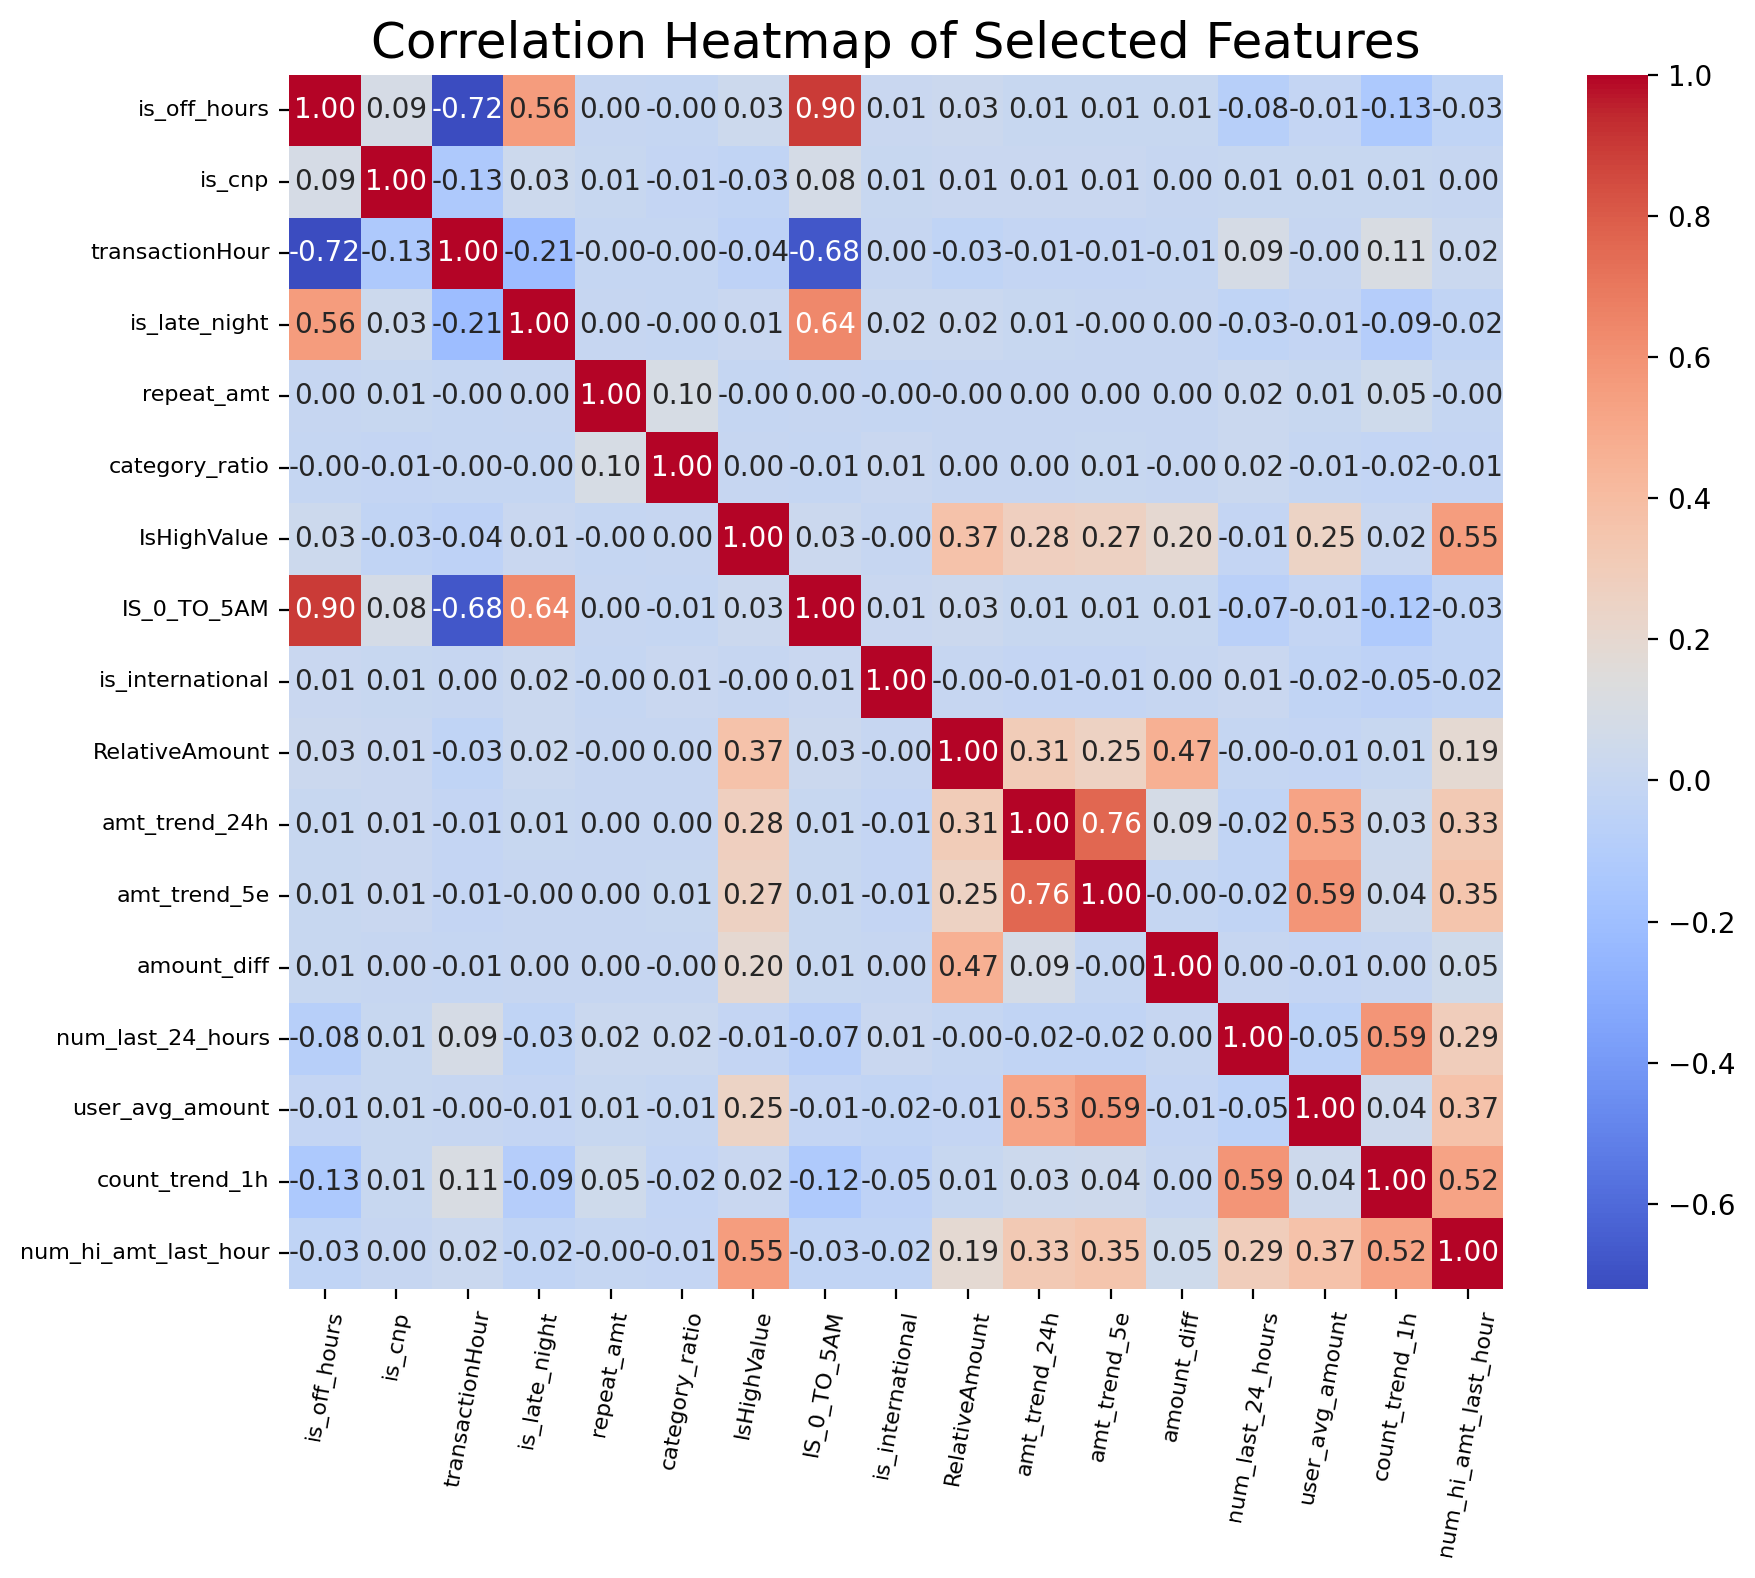

In [ ]:
# List of selected features for the heatmap
selected_features = [
    'is_off_hours', 'is_cnp', 'transactionHour','is_late_night',
    'repeat_amt', 'category_ratio', 'IsHighValue',  'IS_0_TO_5AM',
    'is_international', 'RelativeAmount', 'amt_trend_24h', 'amt_trend_5e',
    'amount_diff', 'num_last_24_hours', 'user_avg_amount', 'count_trend_1h','num_hi_amt_last_hour'
]

# Ensure the selected features exist in the dataframe
df_selected = df[selected_features]

# Calculate the correlation matrix for the selected features
corr_matrix_selected = df_selected.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_selected, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)

plt.title('Correlation Heatmap of Selected Features', fontsize=18)
plt.xticks(rotation=80, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


df.dropdfddfdfdf.drop()dfdef d# <font color='red'>TIP</font>
### Make a code block below that will read in a dataset and perform all calculations needed, using the code that's working to generate the desired feature(s). This will make feature engineering faster for new datasets or old ones that you'd like to add more features to. Then have it save the dateset with features to desired location.